# Rice Grain Classifier — Deep Learning Based Rice Variety Classification

This notebook walks through the full pipeline: dataset exploration, preprocessing, augmentation, training a custom CNN, training a VGG16 transfer-learning model, evaluation, model comparison, and single-image prediction.

It reuses the functions defined in `src/` so that the notebook and the standalone scripts (`train_cnn.py`, `train_vgg16.py`, `evaluate.py`, `predict.py`) stay perfectly in sync — no duplicated logic.

> Run this notebook from the `notebooks/` folder with the project's virtual environment activated as the Jupyter kernel.

## 1. Imports

In [ ]:
import os
import sys

# Allow importing the src/ package from the notebooks/ folder
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_preprocessing import (
    discover_classes,
    collect_image_records,
    stratified_split,
    dataset_statistics,
    plot_sample_images,
    records_to_arrays,
)

print("TensorFlow / project imports ready.")

## 2. Dataset Exploration

In [ ]:
class_names = discover_classes()
print(f"Discovered classes: {class_names}")

records = collect_image_records()
print(f"Total valid images found: {len(records)}")

## 3. Class Distribution

In [ ]:
stats = dataset_statistics(records)
stats_df = pd.DataFrame(list(stats.items()), columns=["Class", "Count"])
display(stats_df)

stats_df.plot(kind="bar", x="Class", y="Count", legend=False, figsize=(8, 4), title="Class Distribution")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

## 4. Sample Image Visualization

In [ ]:
fig = plot_sample_images(records, class_names, samples_per_class=3)
plt.show()

## 5. Data Preprocessing — Train / Validation / Test Split

In [ ]:
train_records, val_records, test_records = stratified_split(records)
print(f"Train: {len(train_records)} | Validation: {len(val_records)} | Test: {len(test_records)}")

# Sanity check: no overlap between splits (no data leakage)
train_paths = {r.path for r in train_records}
val_paths = {r.path for r in val_records}
test_paths = {r.path for r in test_records}
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
print("No data leakage detected between splits.")

## 6. Data Augmentation Preview

In [ ]:
from src.data_preprocessing import build_train_augmentor, load_image_as_array

augmentor = build_train_augmentor()
sample_img = load_image_as_array(train_records[0].path)
sample_batch = np.expand_dims(sample_img, axis=0)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
gen_iter = augmentor.flow(sample_batch, batch_size=1)
for ax in axes:
    augmented = next(gen_iter)[0]
    ax.imshow(np.clip(augmented, 0, 1))
    ax.axis("off")
fig.suptitle("Augmentation Examples")
plt.show()

## 7. Train the Custom CNN

For a full training run, use the standalone script from a terminal instead of the notebook (it is faster and easier to monitor):

```powershell
python src/train_cnn.py
```

The cell below calls the same `main()` function so the notebook can also trigger training directly if desired.

In [ ]:
from src.train_cnn import main as train_cnn_main

# Uncomment to train from within the notebook (can take a long time depending on dataset size / hardware):
# train_cnn_main()

## 8. CNN Evaluation

In [ ]:
from src.evaluate import evaluate_model, get_test_set, load_class_names, plot_training_history

class_names = load_class_names()
X_test, y_test = get_test_set(class_names)

cnn_result = evaluate_model(config.CNN_MODEL_PATH, "CNN", X_test, y_test, class_names, preprocess="cnn")
cnn_result

In [ ]:
plot_training_history(
    config.CNN_HISTORY_PATH,
    os.path.join(config.RESULTS_DIR, "cnn_training_history.png"),
    "CNN",
)

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\uyasa\Downloads\rice-grain-classifier


## 9. Train VGG16 (Transfer Learning)

```powershell
python src/train_vgg16.py
```

In [18]:
from src.train_vgg16 import main as train_vgg16_main

train_vgg16_main()

[INFO] Discovering classes and loading dataset...
[INFO] Classes (5): ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
[INFO] Train: 52500 | Val: 11250 | Test: 11250
[INFO] Loading images into memory as arrays...


MemoryError: Unable to allocate 29.4 GiB for an array with shape (52500, 224, 224, 3) and data type float32

## 10. VGG16 Evaluation

In [ ]:
vgg16_result = evaluate_model(config.VGG16_MODEL_PATH, "VGG16", X_test, y_test, class_names, preprocess="vgg16")
vgg16_result

In [ ]:
plot_training_history(
    config.VGG16_HISTORY_PATH,
    os.path.join(config.RESULTS_DIR, "vgg16_training_history.png"),
    "VGG16",
)

## 11. Model Comparison

In [ ]:
results = [r for r in [cnn_result, vgg16_result] if r is not None]
comparison_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
comparison_df.to_csv(os.path.join(config.RESULTS_DIR, "model_comparison.csv"), index=False)
comparison_df

## 12. Prediction Examples

In [ ]:
from src.predict import predict_image

# Replace with a real path to an image once a model has been trained
example_image_path = test_records[0].path if test_records else None

if example_image_path and os.path.exists(config.CNN_MODEL_PATH):
    result = predict_image(example_image_path, model_type="cnn")
    print(f"Predicted Variety: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print("Probabilities:", result["probabilities"])
else:
    print("Train the CNN model first (python src/train_cnn.py) to run a live prediction example.")

In [1]:
import sys
print("Python:", sys.executable)

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("All imports working!")

Python: c:\Users\uyasa\Downloads\rice-grain-classifier\.venv\Scripts\python.exe
TensorFlow: 2.16.1
NumPy: 1.26.4
Pandas: 3.0.5
All imports working!


In [2]:
import os

DATASET_DIR = "../dataset"

classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, folder))
])

print("Classes:", classes)

for cls in classes:
    folder_path = os.path.join(DATASET_DIR, cls)
    count = len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"{cls}: {count} images")

Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Arborio: 15000 images
Basmati: 15000 images
Ipsala: 15000 images
Jasmine: 15000 images
Karacadag: 15000 images


Image: Arborio (1).jpg
Size: (250, 250)
Mode: RGB


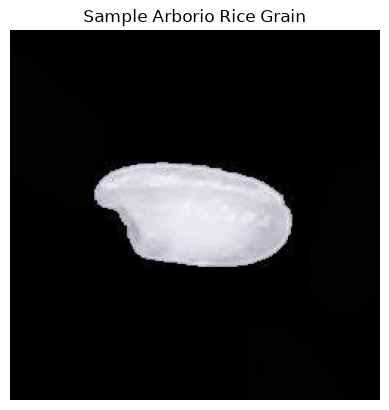

In [3]:
from PIL import Image
import os
import matplotlib.pyplot as plt

sample_folder = os.path.join(DATASET_DIR, "Arborio")

images = [
    f for f in os.listdir(sample_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_path = os.path.join(sample_folder, images[0])

img = Image.open(image_path)

print("Image:", images[0])
print("Size:", img.size)
print("Mode:", img.mode)

plt.imshow(img)
plt.title("Sample Arborio Rice Grain")
plt.axis("off")
plt.show()

## 4. Dataset Preparation and Data Augmentation

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

DATASET_DIR = "../dataset"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

validation_generator = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print("Class indices:")
print(train_generator.class_indices)

print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)

Found 60000 images belonging to 5 classes.
Found 15000 images belonging to 5 classes.
Class indices:
{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3, 'Karacadag': 4}
Training images: 60000
Validation images: 15000


## 5. Custom CNN Model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 5

cnn_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,827,141 (37.49 MB)

 Trainable params: 9,827,141 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=1
)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1799s 960ms/step - accuracy: 0.9359 - loss: 0.1788 - val_accuracy: 0.9890 - val_loss: 0.0347


In [9]:
# Save the trained Custom CNN model
cnn_model.save("../models/custom_cnn.keras")

print("Custom CNN model saved successfully!")

Custom CNN model saved successfully!


In [10]:
# Evaluate Custom CNN on validation data
val_loss, val_accuracy = cnn_model.evaluate(validation_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 266ms/step - accuracy: 0.9867 - loss: 0.0384
Validation Loss: 0.038389794528484344
Validation Accuracy: 0.9867333173751831


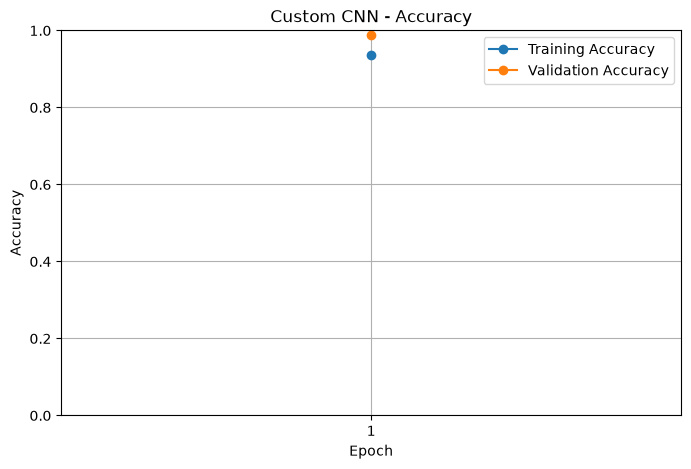

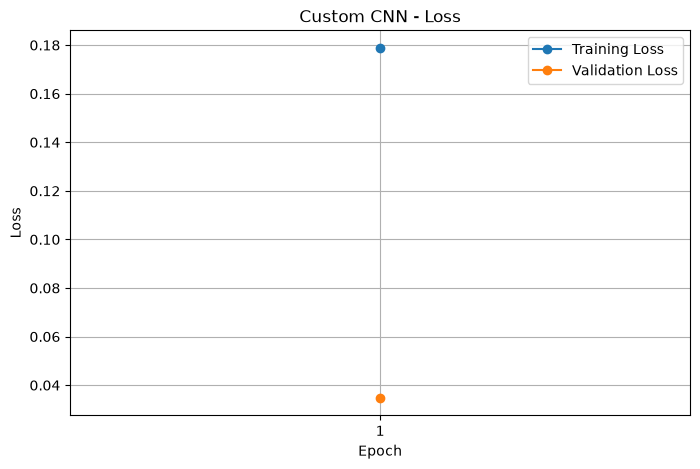

In [12]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["accuracy"]) + 1)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)
plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Custom CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs_range))
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


# Loss
plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    epochs_range,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Custom CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs_range))
plt.legend()
plt.grid(True)
plt.show()

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 270ms/step


<Figure size 800x600 with 0 Axes>

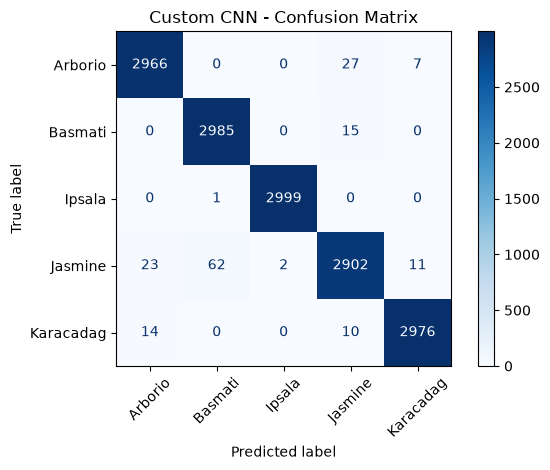

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Reset validation generator
validation_generator.reset()

# Get predictions
predictions = cnn_model.predict(validation_generator)

# Convert probabilities to predicted class numbers
y_pred = np.argmax(predictions, axis=1)

# Actual class numbers
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Custom CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
print("Custom CNN - Classification Report")
print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Custom CNN - Classification Report

              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99      3000
     Basmati       0.98      0.99      0.99      3000
      Ipsala       1.00      1.00      1.00      3000
     Jasmine       0.98      0.97      0.97      3000
   Karacadag       0.99      0.99      0.99      3000

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000

